In [39]:
import pyarrow.feather as feather
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plots import *

In [18]:
table = feather.read_table('../dataset/data_andre.feather', memory_map=True)
df= table.to_pandas()
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2,2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
import pandas as pd

# 0) Clean dates
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# 1) Collapse to daily store totals (handles multiple items per day)
daily = (
    df.groupby(["store_id", "date"], as_index=False)["value"]
      .sum()
)

# --- Option A: working day = any activity row (nonzero sales) ---
open_days = daily[daily["value"] > 0]

# Per-store list of working dates
working_days_by_store = (
    open_days.groupby("store_id")["date"]
             .apply(lambda s: sorted(s.unique()))
             .to_dict()
)

# Example: working days for a specific store_id
store_id = 6269
working_days_store = working_days_by_store.get(store_id, [])

print(f"{store_id} has {len(working_days_store)} working days from {open_days['date'].min().date()} to {open_days['date'].max().date()}")
print()

# --- Determine CLOSED DAYS for the store ---
min_date_global = df["date"].min()
max_date_global = df["date"].max()

# Generate all dates in the global range
all_dates = pd.date_range(start=min_date_global, end=max_date_global, freq='D')

# Convert working_days_store to set for efficient lookup
working_days_set = set(working_days_store)

# Closed days = dates NOT in working days
closed_days_store = [d for d in all_dates if d not in working_days_set]

print(f"Store {store_id} Closure Analysis:")
print(f"  Total possible days: {len(all_dates)}")
print(f"  Working days (nonzero sales): {len(working_days_store)}")
print(f"  Closed/inactive days: {len(closed_days_store)}")
print(f"  Closure rate: {len(closed_days_store) / len(all_dates) * 100:.1f}%")
print()

# Analyze closure patterns (consecutive closure periods)
if closed_days_store:
    closed_days_sorted = sorted(closed_days_store)
    closure_periods = []
    period_start = closed_days_sorted[0]
    period_end = closed_days_sorted[0]
    
    for i in range(1, len(closed_days_sorted)):
        if (closed_days_sorted[i] - closed_days_sorted[i-1]).days == 1:
            # Continue current period
            period_end = closed_days_sorted[i]
        else:
            # End current period, start new one
            closure_periods.append((period_start, period_end, (period_end - period_start).days + 1))
            period_start = closed_days_sorted[i]
            period_end = closed_days_sorted[i]
    
    # Add final period
    closure_periods.append((period_start, period_end, (period_end - period_start).days + 1))
    
    print(f"Closure periods (consecutive closures): {len(closure_periods)}")
    print(f"Average closure period length: {sum(p[2] for p in closure_periods) / len(closure_periods):.1f} days")
    print()
    
    # Show top closure periods
    print("Top 5 longest closure periods:")
    for start, end, duration in sorted(closure_periods, key=lambda x: x[2], reverse=True)[:5]:
        print(f"  {start.date()} to {end.date()}: {duration} days")


6269 has 760 working days from 2021-01-23 to 2023-02-22

Store 6269 Closure Analysis:
  Total possible days: 761
  Working days (nonzero sales): 760
  Closed/inactive days: 1
  Closure rate: 0.1%

Closure periods (consecutive closures): 1
Average closure period length: 1.0 days

Top 5 longest closure periods:
  2022-12-25 to 2022-12-25: 1 days


In [21]:
is_christmas = (daily["date"].dt.month == 12) & (daily["date"].dt.day == 25)
daily.loc[is_christmas & (daily["store_id"] == store_id)]

,store_id,date,value
336,6269,2021-12-25,2
701,6269,2022-12-25,0


In [22]:
import holidays
import pandas as pd

# make sure date column is datetime
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# define the full date range of your dataset
min_date, max_date = df["date"].min(), df["date"].max()

# generate US federal holidays within that range
us_holidays = holidays.UnitedStates(years=range(min_date.year, max_date.year + 1), observed=True)
holiday_dates = [pd.Timestamp(d) for d in us_holidays.keys() if min_date <= pd.Timestamp(d) <= max_date]

daily = (
    df.groupby(["store_id", "date"], as_index=False)["value"]
      .sum()
      .rename(columns={"value": "sales"})
)

# .loc only on holidays
daily_holidays = daily.loc[daily["date"].isin(holiday_dates)]
daily_holidays

,store_id,date,sales
23,6269,2021-02-15,8877
128,6269,2021-05-31,8573
146,6269,2021-06-18,9654
147,6269,2021-06-19,10513
162,6269,2021-07-04,8984
163,6269,2021-07-05,9581
226,6269,2021-09-06,9898
261,6269,2021-10-11,9386
292,6269,2021-11-11,8776
306,6269,2021-11-25,3393


In [23]:
len(df["item_id"].unique())

1427

In [24]:
df["item_id"].value_counts()

item_id
27        761
901498    761
6032      761
901555    761
6035      761
         ... 
79879     595
151824    591
210048    581
151827    578
151825    569
Name: count, Length: 1427, dtype: int64

In [25]:
df["cat_label"].unique()

array(['refrigerated drnks', 'carbonated sft drnks',
       'juices drnks shelf stbl', 'dairy chs', 'sprd btr mrgrn', 'yogurt',
       'rte cereal', 'sour cream', 'milknplant based bevs',
       'bottled water', 'dy non dy crm', 'eggs egg substitutes',
       'sparkling seltzer mixer', 'dairy cream', 'refrig dsrts',
       'refrigerated baked gds', 'new age bevs', 'hot cereal', 'itln chs',
       'sprt drnk', 'cottage chs', 'cream chs', 'dips refrigerated',
       'aseptic'], dtype=object)

In [26]:
# unique item_id per dep_label
sku_per_dep = (
    df.groupby("dep_label")["item_id"]
      .nunique()
      .sort_values(ascending=False)
)

sku_per_dep


dep_label
pos dept dairy      998
pos dept grocery    429
Name: item_id, dtype: int64

In [27]:
sku_per_cateory = (
    df.groupby("cat_label")["item_id"]
        .nunique()
        .sort_values(ascending=False)
)
sku_per_cateory

cat_label
yogurt                     240
dairy chs                  210
refrigerated drnks         165
carbonated sft drnks       131
milknplant based bevs      105
rte cereal                  89
sparkling seltzer mixer     67
sprd btr mrgrn              51
bottled water               50
dy non dy crm               39
eggs egg substitutes        33
cottage chs                 32
juices drnks shelf stbl     31
dairy cream                 29
new age bevs                27
refrig dsrts                21
refrigerated baked gds      21
cream chs                   17
hot cereal                  16
sour cream                  16
sprt drnk                   16
itln chs                    14
dips refrigerated            5
aseptic                      2
Name: item_id, dtype: int64

In [28]:


n_stores = df["store_id"].nunique()
n_skus = df["item_id"].nunique()


# Create store×SKU panel
panel = df.groupby(["store_id", "item_id"])["date"].agg(['min', 'max', 'count']).reset_index()
panel.columns = ['store_id', 'item_id', 'date_min', 'date_max', 'n_records']

actual_series = len(panel)



In [ ]:
# Select a specific store (using the first one or you can specify a store_id)
selected_store = 6269  # Change this to analyze a different store

# Filter data for the selected store
df_store = df[df["store_id"] == selected_store].copy()

print(f"Analyzing store: {selected_store}")
print(f"Products in store: {df_store['item_id'].nunique()}")

# Define GLOBAL period (from all data, not just this store)
global_min = df["date"].min()
global_max = df["date"].max()
global_span_days = (global_max - global_min).days + 1

print(f"Global date range: {global_min.date()} to {global_max.date()} ({global_span_days} days)")
print(f"Store date range: {df_store['date'].min().date()} to {df_store['date'].max().date()}\n")

# Calculate missingness for each product within this store
# Against the GLOBAL period
product_missingness = (
    df_store.groupby("item_id")
    .agg({
        "date": ["min", "max", "count"]
    })
    .reset_index()
)
product_missingness.columns = ['item_id', 'date_min', 'date_max', 'actual_records']

# Expected records = GLOBAL span (all products should have records across full global period)
product_missingness['expected_records'] = global_span_days

# Calculate missingness metrics
product_missingness['missing_records'] = product_missingness['expected_records'] - product_missingness['actual_records']
product_missingness['missingness_rate'] = (product_missingness['missing_records'] / product_missingness['expected_records'] * 100).round(2)
# Calculate missing days BEFORE recordings started
product_missingness['days_missing_before'] = (product_missingness['date_min'] - global_min).dt.days

# Calculate missing days AFTER recordings ended
product_missingness['days_missing_after'] = (global_max - product_missingness['date_max']).dt.days
# Sort by missingness rate
product_missingness_sorted = product_missingness.sort_values('days_missing_after', ascending=False)

product_missingness_sorted


Available stores: [np.int64(6269)]
Total stores: 1

Analyzing store: 6269
Products in store: 1427
Global date range: 2021-01-23 to 2023-02-22 (761 days)
Store date range: 2021-01-23 to 2023-02-22



,item_id,date_min,date_max,actual_records,expected_records,missing_records,missingness_rate,days_missing_before,days_missing_after
812,151825,2021-01-23,2022-08-14,569,761,192,25.23,0,192
814,151827,2021-01-23,2022-08-23,578,761,183,24.05,0,183
927,210048,2021-01-23,2022-08-26,581,761,180,23.65,0,180
811,151824,2021-01-23,2022-09-05,591,761,170,22.34,0,170
577,79879,2021-01-23,2022-09-09,595,761,166,21.81,0,166
...,...,...,...,...,...,...,...,...,...
559,70080,2021-01-23,2023-02-22,761,761,0,0.00,0,0
558,70079,2021-01-23,2023-02-22,761,761,0,0.00,0,0
557,70077,2021-01-23,2023-02-22,761,761,0,0.00,0,0
556,70076,2021-01-23,2023-02-22,761,761,0,0.00,0,0


In [52]:
# Identify products that started late or ended early and impute zeros

# Get global date range
global_min = df["date"].min()
global_max = df["date"].max()
date_range = pd.date_range(start=global_min, end=global_max, freq='D')

print("=" * 100)
print("IMPUTING ZEROS FOR LATE STARTS AND EARLY STOPS")
print("=" * 100)

# Create a complete store-item-date panel
panel_complete = df.groupby(["store_id", "item_id"]).agg({
    "date": ["min", "max"]
}).reset_index()
panel_complete.columns = ['store_id', 'item_id', 'date_min', 'date_max']

# Identify:
# 1. Products that started later than global_min
# 2. Products that stopped earlier than global_max
panel_complete['started_late'] = panel_complete['date_min'] > global_min
panel_complete['ended_early'] = panel_complete['date_max'] < global_max

products_with_gaps = panel_complete[
    (panel_complete['started_late']) | (panel_complete['ended_early'])
]

print(f"\nProducts with start/end gaps:")
print(f"  Started late: {products_with_gaps['started_late'].sum()}")
print(f"  Ended early: {products_with_gaps['ended_early'].sum()}")
print(f"  Total (any gap): {len(products_with_gaps)}\n")

# Impute zeros
df_imputed = df.copy()

for idx, row in products_with_gaps.iterrows():
    store_id = row['store_id']
    item_id = row['item_id']
    date_min = row['date_min']
    date_max = row['date_max']
    
    # Dates before product started (impute with zero)
    # Use a template row to carry over labels and set promo fields to 0
    template = df[(df["store_id"] == store_id) & (df["item_id"] == item_id)].iloc[0].copy()
    promo_cols = [c for c in df.columns if c.startswith("promo_")]

    if row['started_late']:
        dates_before_start = pd.date_range(start=global_min, end=date_min - pd.Timedelta(days=1), freq='D')
        for date in dates_before_start:
            new_row = template.copy()
            new_row["date"] = date
            new_row["value"] = 0
            new_row[promo_cols] = 0
            df_imputed = pd.concat([df_imputed, pd.DataFrame([new_row])], ignore_index=True)

    # Dates after product stopped (impute with zero)
    if row['ended_early']:
        dates_after_end = pd.date_range(start=date_max + pd.Timedelta(days=1), end=global_max, freq='D')
        for date in dates_after_end:
            new_row = template.copy()
            new_row["date"] = date
            new_row["value"] = 0
            new_row[promo_cols] = 0
            df_imputed = pd.concat([df_imputed, pd.DataFrame([new_row])], ignore_index=True)

# Remove duplicates (keep original records, discard new zeros if they somehow overlap)
df_imputed = df_imputed.drop_duplicates(subset=['date', 'store_id', 'item_id'], keep='first')
df_imputed = df_imputed.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

print(f"Original dataset shape: {df.shape}")
print(f"After imputation shape: {df_imputed.shape}")
print(f"New zero records added: {df_imputed.shape[0] - df.shape[0]}")




IMPUTING ZEROS FOR LATE STARTS AND EARLY STOPS

Products with start/end gaps:
  Started late: 165
  Ended early: 355
  Total (any gap): 467

Original dataset shape: (1082371, 24)
After imputation shape: (1085947, 24)
New zero records added: 3576


In [ ]:
df_imputed

In [46]:
df_imputed.reset_index().to_feather("df_imputed.feather")

In [42]:
# Verify: check missingness again for a sample product
sample_product = products_with_gaps.iloc[0]
sample_store = sample_product['store_id']
sample_item = 151825

sample_data = df_imputed[
    (df_imputed['store_id'] == sample_store) & 
    (df_imputed['item_id'] == sample_item)
].sort_values('date')

print(f"\nVerification - Sample product {sample_item} in store {sample_store}:")
print(f"  Date range in imputed data: {sample_data['date'].min().date()} to {sample_data['date'].max().date()}")
print(f"  Total records: {len(sample_data)}")
print(f"  Records with value=0: {(sample_data['value'] == 0).sum()}")
print(f"  Original data had: {df[(df['store_id'] == sample_store) & (df['item_id'] == sample_item)].shape[0]} records")



Verification - Sample product 151825 in store 6269:
  Date range in imputed data: 2021-01-23 to 2023-02-22
  Total records: 761
  Records with value=0: 211
  Original data had: 569 records


Product ID: 151825
Date range: 2021-01-23 00:00:00 to 2023-02-22 00:00:00
Total records: 761
Non-zero sales: 550

Value statistics:
count    761.000000
mean      13.929041
std       11.975752
min        0.000000
25%        0.000000
50%       14.000000
75%       21.000000
max       63.000000
Name: value, dtype: float64


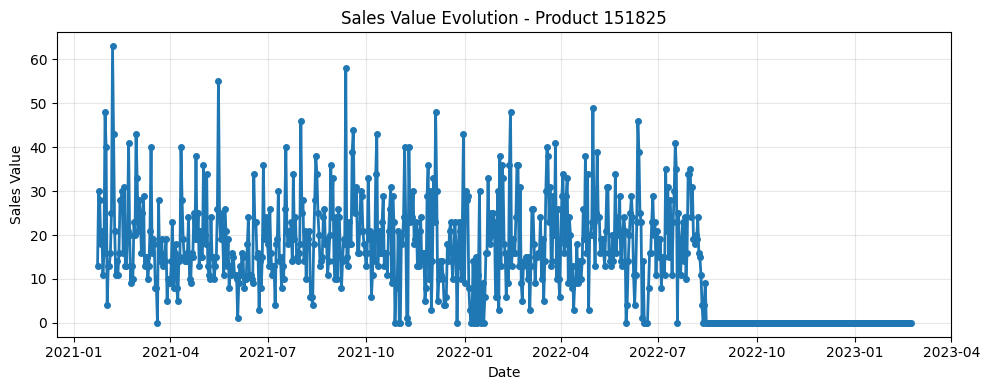

(<Axes: title={'center': 'Sales Value Evolution - Product 151825'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23     13
 1   2021-01-24     30
 2   2021-01-25     28
 3   2021-01-26     18
 4   2021-01-27     21
 ..         ...    ...
 756 2023-02-18      0
 757 2023-02-19      0
 758 2023-02-20      0
 759 2023-02-21      0
 760 2023-02-22      0
 
 [761 rows x 2 columns],
 {'product_id': 151825,
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2023-02-22 00:00:00'),
  'total_records': 761,
  'non_zero_sales': 550,
  'describe': count    761.000000
  mean      13.929041
  std       11.975752
  min        0.000000
  25%        0.000000
  50%       14.000000
  75%       21.000000
  max       63.000000
  Name: value, dtype: float64})

In [45]:
plot_product_value_evolution(df_imputed, selected_product=151825, date_col='date', value_col='value')

In [49]:
# Ratio of zero-sales days to total days per product
zero_sales_ratio = (
    df_imputed.assign(is_zero=df_imputed["value"].eq(0))
    .groupby("item_id", as_index=False)
    .agg(
        total_days=("value", "size"),
        zero_days=("is_zero", "sum")
    )
)
zero_sales_ratio["zero_sales_ratio"] = zero_sales_ratio["zero_days"] / zero_sales_ratio["total_days"]
zero_sales_ratio = zero_sales_ratio.sort_values("zero_sales_ratio", ascending=False)

zero_sales_ratio.head()


,item_id,total_days,zero_days,zero_sales_ratio
608,87566,761,261,0.34297
1276,656409,761,261,0.34297
732,129833,761,261,0.34297
1270,652014,761,261,0.34297
215,13255,761,261,0.34297
